In [1]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

llm = ChatOllama(model="qwen3:1.7b")

c:\Users\wengshang.hoo\AppData\Local\miniconda3\envs\ai_sl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from ddgs import DDGS

@tool
def web_search(query: str, num_results: int = 10) -> str:
    """
    Use this tool when you want to search the web for information. The query parameter is the search query, and number_results specifies how many results to return. The output should be a string containing the search results.

    Args:
        query (str): The search query.
        number_results (int, optional): The number of search results to return. Defaults to 10.

    Returns:
        Formatted search results with titles, descriptions, and URLs.
    """

    results = DDGS().text(query, max_results=num_results)

    if not results:
        return "No results found."
    
    formatted_results = [f"Search results for search query: {query}\n"]

    for i, result in enumerate(results, 1):
        title = result.get('title', 'No title')
        href = result.get('href', '')
        body = result.get('body', 'No description available')

        text = f"{i}. **{title}**\n   {body}\n   {href}"

        formatted_results.append(text)

    return "\n\n".join(formatted_results)

In [7]:
result = web_search.invoke({'query': 'python tutorial', 'num_results':3})
print(result)

Search results for search query: python tutorial


1. **Black Horse Programmer Python Tutorial**
   The Black Horse Programmer Python zero-foundation full tutorial on Bilibili. To locate it, use search keywords: “黑马程序员 python零基础全套教程”; or “黑马程序员 8天python从入门到精通”; or “黑马程序员python教程 BV1qW4y1a7fU”. After searching, sort by “comprehensive” or “playback volume”; the first or top results match (titles usually include “8天python从入门到精通” or “零基础全套”, UP主 is Black Horse Programmer official or related).
   https://grokipedia.com/page/Black_Horse_Programmer_Python_Tutorial

2. **Python Tutorial - W3Schools**
   Download Python from the official Python web site: https://python.org. Well organized and easy to understand Web building tutorials with lots of examples of how to use HTML, CSS, JavaScript, SQL, Python, PHP, Bootstrap, Java, XML and more.
   https://www.w3schools.com/python/

3. **The Python Tutorial — Python 3.14.3 documentation**
   2 days ago · This tutorial introduces the reader informally

In [17]:
from langgraph.graph import add_messages

class AgentState(TypedDict):
    messages: Annotated[list,add_messages]
    research: str
    critique: str
    iterations: int

def researcher_node(state: AgentState) -> str:
    
    llm_with_tools = llm.bind_tools([web_search])

    critique = state.get('critique', '')
    iteration = state.get('iterations', 0)

    feedback_prompt = ""

    if critique:
        feedback_prompt = f"""
            Here is the critique of the previous iteration: {critique}. 
            Address the missing points in your next research.
        """
    
    system_prompt = SystemMessage(f"""
        You are a research agent with web search capabilities.
        {feedback_prompt}
        INSTRUCTIONS:
        1. **MUST use web_search tool** first to gather information
        2. Provide comprehensive research based on search results

        Always call **web_search** before responding.
    """)

    messages = [system_prompt] + state['messages']

    response = llm_with_tools.invoke(messages)

    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            print(f"Call tool {tc.get('name','')} with arguments {tc.get('args','?')}")
    else:
        print(f"Iteration number: {iteration + 1}")

    return {"messages": [response]}

def critique_node(state: AgentState):

    messages = state['messages']
    iteration = state['iterations']

    research_content = messages[-1].content

    system_prompt = SystemMessage("""
        You are a critique agent. Evaluate if research is good enough.
        
        Check:
        1. Does it answer the main question?
        2. Is there reasonable detail?
        
        Response Format:
        DECISION: APPROVE or REVISE
        
        Be lenient. APPROVE if research is decent enough.
        Only REVISE if critical information is completely missing.
    """)

    critique_prompt = HumanMessage(f"""
                                    Evaluate this research:
                                   {research_content}
                                   """)
    
    messages = [system_prompt, critique_prompt]

    response = llm.invoke(messages)

    print(f"[CRITIQUE] Iteration {iteration + 1}")

    return {
        "critique": response.content,
        'research': research_content,
        'iteration': iteration + 1
    }

In [18]:
def route_node(state: AgentState):
    last = state['messages'][-1]
    
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    else:
        return "critique"

In [19]:
MAX_ITERATIONS = 10
def check_approval(state:AgentState):
    critique = state.get('critique', '')
    iterations = state.get('iterations', 0)

    if iterations >= MAX_ITERATIONS:
        print(f"[SYSTEM] Max iterations ({MAX_ITERATIONS}) reached. Stopping...")
        return END
    
    if 'APPROVE' in critique.upper():
        print(f"[SYSTEM] Research approved after ({iterations} iterations).")
        return END
    
    else:
        print(f"[SYSTEM] Revision needed. continuing iteration {iterations + 1}")
        return "research"

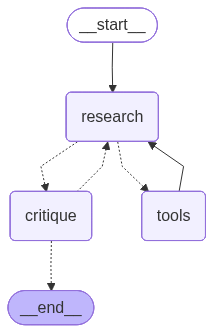

In [20]:
builder = StateGraph(AgentState)

builder.add_node("research",researcher_node)
builder.add_node("critique",critique_node)
builder.add_node("tools",ToolNode([web_search]))

builder.add_edge(START,"research")
builder.add_conditional_edges("research",route_node,['tools','critique'])
builder.add_edge("tools","research")
builder.add_conditional_edges("critique",check_approval,['research',END])

graph = builder.compile()
graph

In [21]:
result = graph.invoke({'messages':[HumanMessage("What is the latest mac chips by today?")],'iterations':0})
result

Call tool web_search with arguments {'query': 'latest Mac chips 2023', 'number_results': 5}
Iteration number: 1
[CRITIQUE] Iteration 1
[SYSTEM] Research approved after (0 iterations).


{'messages': [HumanMessage(content='What is the latest mac chips by today?', additional_kwargs={}, response_metadata={}, id='9d7a0478-d277-4425-a642-fbfb83ff957f'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-01T10:10:20.565498Z', 'done': True, 'done_reason': 'stop', 'total_duration': 28264899500, 'load_duration': 3324801600, 'prompt_eval_count': 286, 'prompt_eval_duration': 5999507400, 'eval_count': 373, 'eval_duration': 18741219000, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019ca8e0-36a7-7b41-920c-a0952acb67d4-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'latest Mac chips 2023', 'number_results': 5}, 'id': 'b3e2253e-6237-4fb8-97f3-6b0d00b141ff', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 286, 'output_tokens': 373, 'total_tokens': 659}),
  ToolMessage(content='Search results for search query: latest Mac chips 2023\n\n\n1. **Appl